In [128]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [129]:
class BatsmanState(TypedDict):

    runs : int
    balls : int
    fours : int
    sixes : int

    sr : float
    bbp : float
    boundary_present : float
    summary : str
    

In [130]:
def calculate_sr(state: BatsmanState):

    sr = (state['runs']/state['balls'])*100


    return {'sr' : sr}

In [131]:
def calculate_bbp(state: BatsmanState):

    bbp = state['balls'] / (state['fours'] + state['sixes'])
   

    return {'bbp' : bbp}

In [132]:
def calculate_boundary_percent(state: BatsmanState):

    boundary_percent = (
        ((state['fours'] * 4) + (state['sixes'] * 6))
        / state['runs']
    ) * 100

    return {'boundary_percent': boundary_percent}

In [133]:
def summary(state: BatsmanState):

    summary = f"""
Strike Rate - {state['sr']}
Balls per boundary - {state['bbp']}
Boundary percent - {state['boundary_percent']}
"""

    return {'summary': summary}

In [134]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bbp', calculate_bbp)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bbp')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge(
    ['calculate_sr', 'calculate_bbp', 'calculate_boundary_percent'],
    'summary'
)

graph.add_edge('summary', END)

workflow = graph.compile()

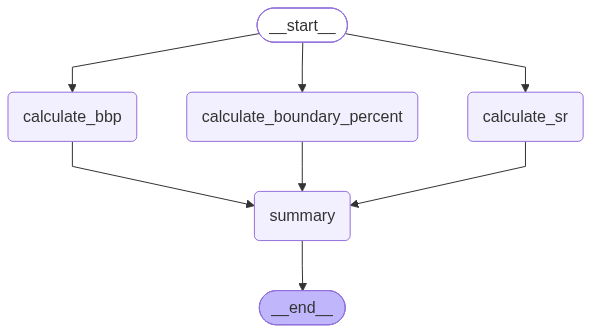

In [135]:
graph.compile()

In [138]:
intial_state = {
    'runs' : 100,
    'balls' : 50,
    'fours' : 6,
    'sixes' : 4,
}

result = workflow.invoke(intial_state)
print(result['summary'])


Strike Rate - 200.00
Balls per boundary - 5.00
Boundary percent - 48.00

